TRUSTTWIN SWaT - PAPER MODE FINAL
Device: cuda
GPU: Tesla T4
Seed: 42
Paper mode: True

[1] Loading SWaT...
Normal shape: (495000, 53)
Attack shape: (449919, 53)

[2] Preparing timestamp and labels...
Total rows: 944919
Labels: {0: 890298, 1: 54621}
Number of numerical features: 51
['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603']

[3] Chronological split before preprocessing...
Train rows: 661443
Validation rows: 141738
Test rows: 141738

[4] Train-only preprocessing...
Remaining NaN: 0

[5] Creating temporal sequences...
Train sequences: (661413, 30, 51)
Validation sequences

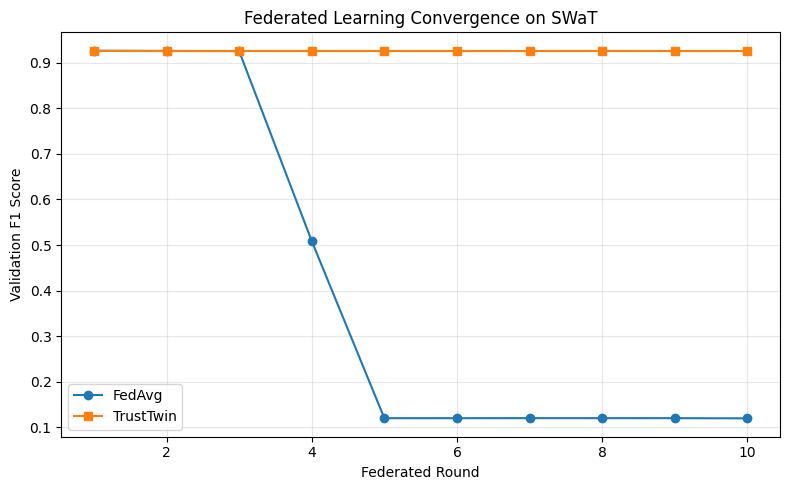

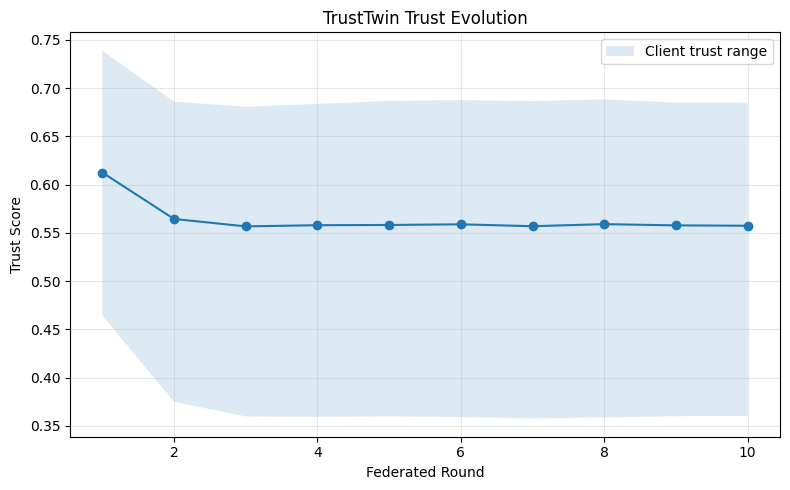

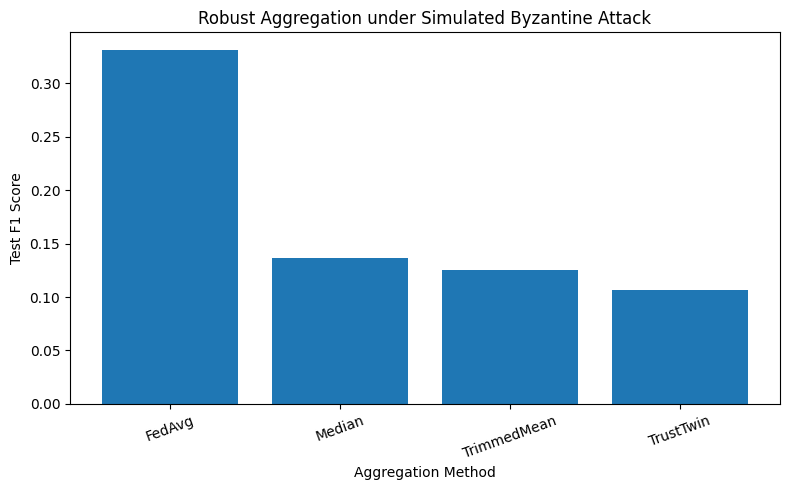

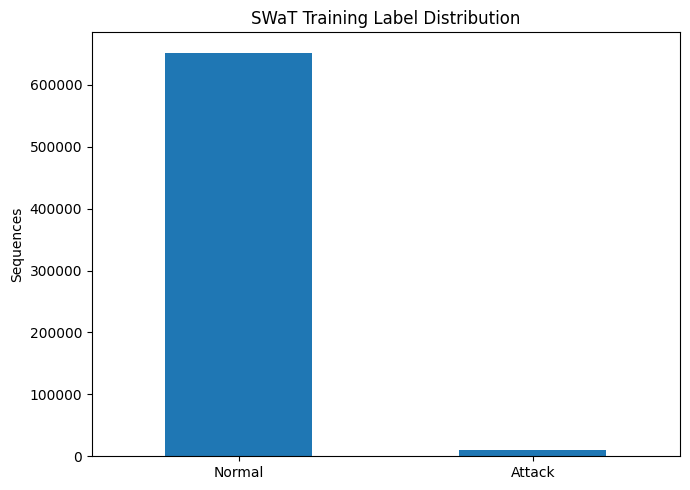

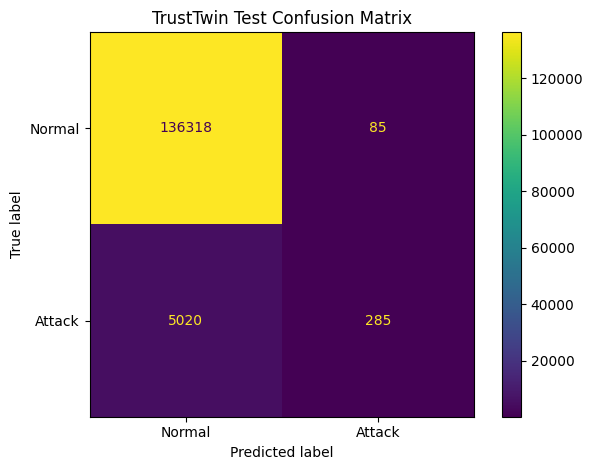


TRUSTTWIN SWaT PAPER MODE RUN COMPLETED

FINAL TEST RESULTS:
           Model  Accuracy  Precision   Recall       F1  Balanced_Accuracy      MCC    AUROC    AUPRC  Threshold  Validation_F1
Centralized_LSTM  0.965224   0.684262 0.131951 0.221239           0.564792 0.290563 0.641930 0.158910       0.95       0.119543
          FedAvg  0.962691   0.543689 0.021112 0.040646           0.510212 0.101756 0.568350 0.111771       0.95       0.120027
       TrustTwin  0.963975   0.770270 0.053723 0.100441           0.526550 0.197523 0.463867 0.155727       0.55       0.925214

Output folder:
/kaggle/working/TrustTwin_SWaT_PAPER

Results:
   FINAL_SWAT_TRUSTTWIN_PAPER_RESULTS.csv
   FedAvg_validation_convergence.csv
   Robust_FL_controlled_comparison.csv
   TrustTwin_client_trust_history.csv
   TrustTwin_validation_convergence.csv
   experiment_config_PAPER_MODE.json
   features.txt
   scaler_mean.npy
   scaler_scale.npy
   train_medians.npy

Graphs:
   01_validation_convergence.png
   02_trust_

In [1]:
# ================================================================
# TRUSTTWIN - SWaT PAPER MODE FINAL
# Reproducible, leakage-controlled, paper-oriented evaluation
# ================================================================
# Kaggle: enable GPU (Tesla T4 is sufficient)
# Dataset expected:
# /kaggle/input/datasets/himalayk/swatdatasethimalay/
#   SWaT_Dataset_Normal_v1.xlsx
#   SWaT_Dataset_Attack_v0.xlsx
# ================================================================

import os
import gc
import json
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay
)

# ================================================================
# 0. PAPER-MODE CONFIGURATION
# ================================================================

PAPER_MODE = True
SEED = 42

# Keep these aligned with the validated V2 pipeline unless explicitly
# changed for an approved experimental ablation.
SEQUENCE_LENGTH = 30
BATCH_SIZE = 512
LEARNING_RATE = 5e-4
CENTRAL_EPOCHS = 10
FL_ROUNDS = 10
LOCAL_EPOCHS = 2
NUM_CLIENTS = 5
MALICIOUS_RATIO = 0.20

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Non-IID partition using label-sorted contiguous shards.
# This creates heterogeneous client class distributions without using
# validation/test data to construct clients.
NON_IID_SHARDS_PER_CLIENT = 2

# Threshold is selected ONLY on validation data and then frozen for test.
THRESHOLD_GRID = np.arange(0.05, 0.951, 0.01)

BASE_PATH = "/kaggle/input/datasets/himalayk/swatdatasethimalay"
NORMAL_FILE = os.path.join(BASE_PATH, "SWaT_Dataset_Normal_v1.xlsx")
ATTACK_FILE = os.path.join(BASE_PATH, "SWaT_Dataset_Attack_v0.xlsx")

WORK_DIR = "/kaggle/working/TrustTwin_SWaT_PAPER"
RESULT_DIR = os.path.join(WORK_DIR, "results")
GRAPH_DIR = os.path.join(WORK_DIR, "graphs")
MODEL_DIR = os.path.join(WORK_DIR, "models")

for folder in [WORK_DIR, RESULT_DIR, GRAPH_DIR, MODEL_DIR]:
    os.makedirs(folder, exist_ok=True)

# ================================================================
# 1. REPRODUCIBILITY + GPU
# ================================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("GPU is not enabled. Kaggle Settings -> Accelerator -> GPU.")

DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("=" * 78)
print("TRUSTTWIN SWaT - PAPER MODE FINAL")
print("=" * 78)
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("Seed:", SEED)
print("Paper mode:", PAPER_MODE)

# ================================================================
# 2. DATA LOADING
# ================================================================

print("\n[1] Loading SWaT...")

if not os.path.exists(NORMAL_FILE) or not os.path.exists(ATTACK_FILE):
    raise FileNotFoundError(
        "Expected SWaT Excel files were not found under: " + BASE_PATH
    )

normal = pd.read_excel(NORMAL_FILE, sheet_name="Normal.csv", header=1)
attack = pd.read_excel(ATTACK_FILE, sheet_name="Combined Data", header=1)

print("Normal shape:", normal.shape)
print("Attack shape:", attack.shape)


def clean_df(df):
    df = df.copy()
    df = df.dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~df.columns.duplicated()]
    return df

normal = clean_df(normal)
attack = clean_df(attack)

normal["dataset_source"] = "normal"
attack["dataset_source"] = "attack"

data = pd.concat([normal, attack], ignore_index=True)
del normal, attack
gc.collect()

# ================================================================
# 3. TIMESTAMP + LABEL + CHRONOLOGICAL ORDER
# ================================================================

print("\n[2] Preparing timestamp and labels...")

data["Timestamp"] = pd.to_datetime(data["Timestamp"], errors="coerce")
data = data.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

data["label"] = (
    data["Normal/Attack"].astype(str).str.strip().str.lower().ne("normal").astype(np.int8)
)

print("Total rows:", len(data))
print("Labels:", data["label"].value_counts().sort_index().to_dict())

# ================================================================
# 4. FEATURE DETECTION
# ================================================================

exclude_cols = ["Timestamp", "Normal/Attack", "dataset_source", "label"]
candidate_cols = [c for c in data.columns if c not in exclude_cols]
features = []

for col in candidate_cols:
    temp = pd.to_numeric(data[col], errors="coerce")
    if temp.notna().mean() >= 0.95:
        features.append(col)
        data[col] = temp

if not features:
    raise RuntimeError("No numerical SWaT features detected.")

print("Number of numerical features:", len(features))
print(features)

# ================================================================
# 5. CHRONOLOGICAL RAW SPLIT BEFORE IMPUTATION/FITTING SCALER
#    This avoids using validation/test statistics in training.
# ================================================================

print("\n[3] Chronological split before preprocessing...")

N = len(data)
train_end = int(N * TRAIN_RATIO)
val_end = int(N * (TRAIN_RATIO + VAL_RATIO))

train_df = data.iloc[:train_end].copy()
val_df = data.iloc[train_end:val_end].copy()
test_df = data.iloc[val_end:].copy()

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

# ================================================================
# 6. TRAIN-ONLY IMPUTATION + SCALING
# ================================================================

print("\n[4] Train-only preprocessing...")

# Convert infinities to NaN in all splits.
for df in [train_df, val_df, test_df]:
    df[features] = df[features].replace([np.inf, -np.inf], np.nan)

# Median imputation learned ONLY from training data.
train_medians = train_df[features].median()
train_df[features] = train_df[features].fillna(train_medians)
val_df[features] = val_df[features].fillna(train_medians)
test_df[features] = test_df[features].fillna(train_medians)

# Any still-missing values are filled with 0 only as a defensive fallback.
train_df[features] = train_df[features].fillna(0.0)
val_df[features] = val_df[features].fillna(0.0)
test_df[features] = test_df[features].fillna(0.0)

X_train_raw = train_df[features].to_numpy(dtype=np.float32)
y_train_raw = train_df["label"].to_numpy(dtype=np.int64)
X_val_raw = val_df[features].to_numpy(dtype=np.float32)
y_val_raw = val_df["label"].to_numpy(dtype=np.int64)
X_test_raw = test_df[features].to_numpy(dtype=np.float32)
y_test_raw = test_df["label"].to_numpy(dtype=np.int64)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val = scaler.transform(X_val_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

print("Remaining NaN:",
      int(np.isnan(X_train).sum() + np.isnan(X_val).sum() + np.isnan(X_test).sum()))

# ================================================================
# 7. TEMPORAL SEQUENCES
# ================================================================

def make_sequences(X, y, seq_len=30):
    n = len(X) - seq_len
    if n <= 0:
        raise ValueError("Split is too small for the selected sequence length.")
    X_seq = np.empty((n, seq_len, X.shape[1]), dtype=np.float32)
    y_seq = np.empty(n, dtype=np.int64)
    for i in range(n):
        X_seq[i] = X[i:i + seq_len]
        y_seq[i] = y[i + seq_len]
    return X_seq, y_seq

print("\n[5] Creating temporal sequences...")
X_train_seq, y_train_seq = make_sequences(X_train, y_train_raw, SEQUENCE_LENGTH)
X_val_seq, y_val_seq = make_sequences(X_val, y_val_raw, SEQUENCE_LENGTH)
X_test_seq, y_test_seq = make_sequences(X_test, y_test_raw, SEQUENCE_LENGTH)

print("Train sequences:", X_train_seq.shape)
print("Validation sequences:", X_val_seq.shape)
print("Test sequences:", X_test_seq.shape)
print("Train label distribution:", pd.Series(y_train_seq).value_counts().sort_index().to_dict())
print("Validation label distribution:", pd.Series(y_val_seq).value_counts().sort_index().to_dict())
print("Test label distribution:", pd.Series(y_test_seq).value_counts().sort_index().to_dict())

# ================================================================
# 8. DATASET / LOADERS
# ================================================================

class SWaTSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, shuffle=False, balanced=False):
    ds = SWaTSequenceDataset(X, y)
    sampler = None

    if balanced:
        yi = np.asarray(y, dtype=np.int64)
        counts = np.bincount(yi, minlength=2)
        class_weights = np.zeros(2, dtype=np.float64)
        for c in range(2):
            if counts[c] > 0:
                class_weights[c] = 1.0 / counts[c]
        sample_weights = class_weights[yi]
        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(sample_weights),
            replacement=True
        )

    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=(shuffle if sampler is None else False),
        sampler=sampler,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True
    )

# ================================================================
# 9. MODEL
# ================================================================

class SWaTLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=96):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(1)


def create_model():
    return SWaTLSTM(input_size=len(features), hidden_size=96).to(DEVICE)

# ================================================================
# 10. TRAIN / PREDICT
# ================================================================

def train_local(model, X, y, epochs=1):
    model = deepcopy(model).to(DEVICE)
    loader = make_loader(X, y, shuffle=True, balanced=True)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    amp_scaler = torch.amp.GradScaler("cuda")

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(xb)
                loss = criterion(logits, yb)
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            amp_scaler.step(optimizer)
            amp_scaler.update()
            total_loss += float(loss.item())
        print(f"      Epoch {epoch + 1}/{epochs} Loss={total_loss / max(1, len(loader)):.4f}")
    return model


def predict_model(model, X, y):
    loader = make_loader(X, y, shuffle=False, balanced=False)
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(xb)
            probs.append(torch.sigmoid(logits).float().cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(labels), np.concatenate(probs)

# ================================================================
# 11. METRICS + VALIDATION-ONLY THRESHOLD
# ================================================================

def find_best_threshold(labels, probabilities):
    best_threshold = 0.5
    best_f1 = -1.0
    for threshold in THRESHOLD_GRID:
        pred = (probabilities >= threshold).astype(np.int8)
        score = f1_score(labels, pred, zero_division=0)
        if score > best_f1:
            best_f1 = float(score)
            best_threshold = float(threshold)
    return best_threshold, best_f1


def metrics_from_prob(labels, probabilities, threshold):
    pred = (probabilities >= threshold).astype(np.int8)
    return {
        "Accuracy": accuracy_score(labels, pred),
        "Precision": precision_score(labels, pred, zero_division=0),
        "Recall": recall_score(labels, pred, zero_division=0),
        "F1": f1_score(labels, pred, zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(labels, pred),
        "MCC": matthews_corrcoef(labels, pred),
        "AUROC": roc_auc_score(labels, probabilities),
        "AUPRC": average_precision_score(labels, probabilities),
        "Threshold": float(threshold),
    }, pred


def validation_threshold(model):
    val_true, val_prob = predict_model(model, X_val_seq, y_val_seq)
    threshold, val_f1 = find_best_threshold(val_true, val_prob)
    return threshold, val_f1


def final_test_once(model, threshold):
    test_true, test_prob = predict_model(model, X_test_seq, y_test_seq)
    metrics, test_pred = metrics_from_prob(test_true, test_prob, threshold)
    return metrics, test_true, test_pred, test_prob

# ================================================================
# 12. FEDERATED CLIENT PARTITION - NON-IID
# ================================================================

def create_non_iid_clients(X, y, num_clients=5, shards_per_client=2, seed=42):
    """
    Sort training sequences by label, divide into shards, and allocate
    multiple shards per client. This produces deterministic label-skew
    non-IID clients while keeping validation/test untouched.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=np.int64)
    indices = np.arange(len(y))
    indices = indices[np.argsort(y, kind="stable")]

    total_shards = num_clients * shards_per_client
    shard_indices = np.array_split(indices, total_shards)
    order = rng.permutation(total_shards)

    clients = []
    for client_id in range(num_clients):
        chosen = order[client_id * shards_per_client:(client_id + 1) * shards_per_client]
        idx = np.concatenate([shard_indices[j] for j in chosen])
        rng.shuffle(idx)
        clients.append({
            "client_id": client_id,
            "indices": idx,
            "X": X[idx],
            "y": y[idx]
        })
    return clients

clients = create_non_iid_clients(
    X_train_seq, y_train_seq,
    NUM_CLIENTS,
    NON_IID_SHARDS_PER_CLIENT,
    SEED
)

print("\n[6] Non-IID clients:")
for c in clients:
    print(
        f"Client {c['client_id']}: n={len(c['X'])}, "
        f"attack_ratio={c['y'].mean():.4f}, "
        f"normal={int((c['y']==0).sum())}, attack={int((c['y']==1).sum())}"
    )

# ================================================================
# 13. FEDAVG
# ================================================================

def fedavg(models, weights):
    total = float(sum(weights))
    state = deepcopy(models[0].state_dict())
    for key in state:
        state[key] = sum(
            models[i].state_dict()[key] * float(weights[i] / total)
            for i in range(len(models))
        )
    return state

# ================================================================
# 14. CENTRALIZED BASELINE
# ================================================================

print("\n" + "=" * 78)
print("CENTRALIZED LSTM BASELINE")
print("=" * 78)

central_model = create_model()
central_model = train_local(central_model, X_train_seq, y_train_seq, CENTRAL_EPOCHS)
central_threshold, central_val_f1 = validation_threshold(central_model)
central_metrics, central_true, central_pred, central_prob = final_test_once(
    central_model, central_threshold
)
central_metrics["Validation_F1"] = central_val_f1
central_metrics["Model"] = "Centralized_LSTM"

print("Centralized validation F1:", round(central_val_f1, 4))
print("Centralized frozen test metrics:", central_metrics)

torch.save(central_model.state_dict(), os.path.join(MODEL_DIR, "central_lstm_paper.pt"))

# ================================================================
# 15. FEDAVG - VALIDATION DURING ROUNDS, TEST ONLY AT END
# ================================================================

print("\n" + "=" * 78)
print("FEDAVG - PAPER MODE")
print("=" * 78)

global_model = create_model()
fed_rounds = []

for rnd in range(1, FL_ROUNDS + 1):
    print(f"\n========== FedAvg Round {rnd}/{FL_ROUNDS} ==========")
    local_models, weights = [], []

    for client in clients:
        print(f"Client {client['client_id']}")
        lm = train_local(global_model, client["X"], client["y"], LOCAL_EPOCHS)
        local_models.append(lm)
        weights.append(len(client["X"]))

    global_model.load_state_dict(fedavg(local_models, weights))
    val_threshold, val_f1 = validation_threshold(global_model)
    val_true, val_prob = predict_model(global_model, X_val_seq, y_val_seq)
    val_metrics, _ = metrics_from_prob(val_true, val_prob, val_threshold)
    fed_rounds.append({
        "Round": rnd,
        "Validation_Accuracy": val_metrics["Accuracy"],
        "Validation_Precision": val_metrics["Precision"],
        "Validation_Recall": val_metrics["Recall"],
        "Validation_F1": val_metrics["F1"],
        "Validation_AUROC": val_metrics["AUROC"],
        "Validation_AUPRC": val_metrics["AUPRC"],
        "Validation_Threshold": val_threshold,
    })
    print(f"Validation F1={val_f1:.4f} | AUROC={val_metrics['AUROC']:.4f} | AUPRC={val_metrics['AUPRC']:.4f}")
    del local_models
    torch.cuda.empty_cache()

fed_round_df = pd.DataFrame(fed_rounds)
fed_round_df.to_csv(os.path.join(RESULT_DIR, "FedAvg_validation_convergence.csv"), index=False)

fed_threshold, fed_val_f1 = validation_threshold(global_model)
fed_metrics, fed_true, fed_pred, fed_prob = final_test_once(global_model, fed_threshold)
fed_metrics["Validation_F1"] = fed_val_f1
fed_metrics["Model"] = "FedAvg"
print("FedAvg frozen test metrics:", fed_metrics)
torch.save(global_model.state_dict(), os.path.join(MODEL_DIR, "fedavg_paper.pt"))

# ================================================================
# 16. TRUSTTWIN TRUST-AWARE FL
# ================================================================
# IMPORTANT: malicious clients are simulated only for the security
# experiment. The trust update uses observable update distance,
# validation performance and historical trust. No test information is used.
# ================================================================

print("\n" + "=" * 78)
print("TRUSTTWIN - PAPER MODE")
print("=" * 78)


def state_distance(old_model, new_model):
    total = 0.0
    old_state = old_model.state_dict()
    new_state = new_model.state_dict()
    for key in old_state:
        a = old_state[key].float()
        b = new_state[key].float()
        total += float(torch.norm(b - a).item())
    return total


def update_norm(model):
    total = 0.0
    for p in model.parameters():
        total += float(torch.norm(p.detach()).item())
    return total


def calculate_trust(old_model, local_model, local_val_f1, previous_trust, security_score):
    distance = state_distance(old_model, local_model)
    quality = 1.0 / (1.0 + distance)
    performance = float(np.clip(local_val_f1, 0.0, 1.0))
    history = float(np.clip(previous_trust, 0.0, 1.0))
    security = float(np.clip(security_score, 0.0, 1.0))
    score = 0.30 * performance + 0.25 * quality + 0.25 * history + 0.20 * security
    return float(np.clip(score, 0.0, 1.0))


def trust_aggregation(models, trust_scores):
    w = np.asarray(trust_scores, dtype=np.float64) + 1e-8
    w = w / w.sum()
    state = deepcopy(models[0].state_dict())
    for key in state:
        state[key] = sum(models[i].state_dict()[key] * float(w[i]) for i in range(len(models)))
    return state

trust_model = create_model()
client_trust = np.ones(NUM_CLIENTS, dtype=np.float64)
trust_rounds = []
trust_client_history = []

malicious_count = max(1, int(round(NUM_CLIENTS * MALICIOUS_RATIO)))
malicious_clients = set(range(malicious_count))

print("Simulated malicious client IDs:", sorted(malicious_clients))

for rnd in range(1, FL_ROUNDS + 1):
    print(f"\n========== TrustTwin Round {rnd}/{FL_ROUNDS} ==========")
    local_models, trust_scores = [], []

    for i, client in enumerate(clients):
        print(f"Client {i}")
        lm = train_local(trust_model, client["X"], client["y"], LOCAL_EPOCHS)

        # Security attack simulation: Byzantine sign-flip.
        # This is the experimental threat model, not a claim about real attackers.
        is_malicious = i in malicious_clients
        if is_malicious:
            print("  -> simulated Byzantine sign-flip attack")
            with torch.no_grad():
                for p in lm.parameters():
                    p.data.mul_(-1.0)
            security_score = 0.1
        else:
            security_score = 1.0

        local_val_true, local_val_prob = predict_model(lm, X_val_seq, y_val_seq)
        local_thr, local_val_f1 = find_best_threshold(local_val_true, local_val_prob)
        trust = calculate_trust(
            trust_model, lm, local_val_f1, client_trust[i], security_score
        )
        client_trust[i] = trust

        trust_scores.append(trust)
        local_models.append(lm)
        trust_client_history.append({
            "Round": rnd,
            "Client": i,
            "Malicious": int(is_malicious),
            "Local_Validation_F1": local_val_f1,
            "Local_Validation_Threshold": local_thr,
            "Trust": trust,
            "Update_Norm": update_norm(lm),
        })
        print(f"  local val F1={local_val_f1:.4f} | trust={trust:.4f}")

    trust_model.load_state_dict(trust_aggregation(local_models, trust_scores))

    val_thr, val_f1 = validation_threshold(trust_model)
    val_true, val_prob = predict_model(trust_model, X_val_seq, y_val_seq)
    val_metrics, _ = metrics_from_prob(val_true, val_prob, val_thr)

    trust_rounds.append({
        "Round": rnd,
        "Validation_Accuracy": val_metrics["Accuracy"],
        "Validation_Precision": val_metrics["Precision"],
        "Validation_Recall": val_metrics["Recall"],
        "Validation_F1": val_metrics["F1"],
        "Validation_AUROC": val_metrics["AUROC"],
        "Validation_AUPRC": val_metrics["AUPRC"],
        "Validation_Threshold": val_thr,
        "Mean_Trust": float(np.mean(trust_scores)),
        "Min_Trust": float(np.min(trust_scores)),
        "Max_Trust": float(np.max(trust_scores)),
    })

    print(
        f"Validation F1={val_metrics['F1']:.4f} | "
        f"AUROC={val_metrics['AUROC']:.4f} | "
        f"AUPRC={val_metrics['AUPRC']:.4f} | "
        f"Mean trust={np.mean(trust_scores):.4f}"
    )

    del local_models
    torch.cuda.empty_cache()

trust_round_df = pd.DataFrame(trust_rounds)
trust_client_df = pd.DataFrame(trust_client_history)
trust_round_df.to_csv(os.path.join(RESULT_DIR, "TrustTwin_validation_convergence.csv"), index=False)
trust_client_df.to_csv(os.path.join(RESULT_DIR, "TrustTwin_client_trust_history.csv"), index=False)

trust_threshold, trust_val_f1 = validation_threshold(trust_model)
trust_metrics, trust_true, trust_pred, trust_prob = final_test_once(trust_model, trust_threshold)
trust_metrics["Validation_F1"] = trust_val_f1
trust_metrics["Model"] = "TrustTwin"
print("TrustTwin frozen test metrics:", trust_metrics)
torch.save(trust_model.state_dict(), os.path.join(MODEL_DIR, "TrustTwin_paper.pt"))

# ================================================================
# 17. ROBUST AGGREGATION COMPARISON - SAME CLIENT UPDATES
# ================================================================
# This is a one-round controlled comparison using exactly the same
# trained local updates and attack configuration for all aggregators.
# Trust scores here are recomputed from the SAME round, rather than
# reusing final state from a different experiment.
# ================================================================

print("\n" + "=" * 78)
print("ROBUST AGGREGATION CONTROLLED COMPARISON")
print("=" * 78)

reference_model = create_model()
robust_local_models = []
robust_trust_scores = []

for i, client in enumerate(clients):
    lm = train_local(reference_model, client["X"], client["y"], LOCAL_EPOCHS)
    is_malicious = i in malicious_clients
    if is_malicious:
        with torch.no_grad():
            for p in lm.parameters():
                p.data.mul_(-1.0)
        sec = 0.1
    else:
        sec = 1.0

    vtrue, vprob = predict_model(lm, X_val_seq, y_val_seq)
    _, local_f1 = find_best_threshold(vtrue, vprob)
    robust_trust_scores.append(calculate_trust(reference_model, lm, local_f1, 1.0, sec))
    robust_local_models.append(lm)


def median_aggregation(models):
    state = {}
    for key in models[0].state_dict().keys():
        stacked = torch.stack([m.state_dict()[key].float() for m in models])
        state[key] = torch.median(stacked, dim=0).values
    return state


def trimmed_mean(models, trim_ratio=0.2):
    state = {}
    for key in models[0].state_dict().keys():
        stacked = torch.stack([m.state_dict()[key].float() for m in models])
        n = stacked.shape[0]
        trim = int(n * trim_ratio)
        if trim == 0 or 2 * trim >= n:
            state[key] = stacked.mean(dim=0)
        else:
            sorted_values, _ = torch.sort(stacked, dim=0)
            state[key] = sorted_values[trim:n-trim].mean(dim=0)
    return state

robust_methods = {}

m = create_model(); m.load_state_dict(fedavg(robust_local_models, [len(c["X"]) for c in clients]))
robust_methods["FedAvg"] = m

m = create_model(); m.load_state_dict(median_aggregation(robust_local_models))
robust_methods["Median"] = m

m = create_model(); m.load_state_dict(trimmed_mean(robust_local_models, 0.2))
robust_methods["TrimmedMean"] = m

m = create_model(); m.load_state_dict(trust_aggregation(robust_local_models, robust_trust_scores))
robust_methods["TrustTwin"] = m

robust_rows = []
for name, model in robust_methods.items():
    thr, vf1 = validation_threshold(model)
    met, _, _, _ = final_test_once(model, thr)
    robust_rows.append({"Method": name, "Validation_F1": vf1, **met})

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv(os.path.join(RESULT_DIR, "Robust_FL_controlled_comparison.csv"), index=False)
print(robust_df.to_string(index=False))

# ================================================================
# 18. FINAL PAPER TABLE
# ================================================================

final_df = pd.DataFrame([
    {k: v for k, v in central_metrics.items()},
    {k: v for k, v in fed_metrics.items()},
    {k: v for k, v in trust_metrics.items()},
])

cols = [
    "Model", "Accuracy", "Precision", "Recall", "F1",
    "Balanced_Accuracy", "MCC", "AUROC", "AUPRC",
    "Threshold", "Validation_F1"
]
final_df = final_df[[c for c in cols if c in final_df.columns]]
final_df.to_csv(os.path.join(RESULT_DIR, "FINAL_SWAT_TRUSTTWIN_PAPER_RESULTS.csv"), index=False)

# ================================================================
# 19. PAPER-READY GRAPHS
# ================================================================

print("\n[7] Generating paper graphs...")

plt.figure(figsize=(8, 5))
plt.plot(fed_round_df["Round"], fed_round_df["Validation_F1"], marker="o", label="FedAvg")
plt.plot(trust_round_df["Round"], trust_round_df["Validation_F1"], marker="s", label="TrustTwin")
plt.xlabel("Federated Round")
plt.ylabel("Validation F1 Score")
plt.title("Federated Learning Convergence on SWaT")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "01_validation_convergence.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(trust_round_df["Round"], trust_round_df["Mean_Trust"], marker="o")
plt.fill_between(
    trust_round_df["Round"].to_numpy(),
    trust_round_df["Min_Trust"].to_numpy(),
    trust_round_df["Max_Trust"].to_numpy(),
    alpha=0.15,
    label="Client trust range"
)
plt.xlabel("Federated Round")
plt.ylabel("Trust Score")
plt.title("TrustTwin Trust Evolution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "02_trust_evolution.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(robust_df["Method"], robust_df["F1"])
plt.xlabel("Aggregation Method")
plt.ylabel("Test F1 Score")
plt.title("Robust Aggregation under Simulated Byzantine Attack")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "03_robust_aggregation.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
pd.Series(y_train_seq).value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Normal", "Attack"], rotation=0)
plt.ylabel("Sequences")
plt.title("SWaT Training Label Distribution")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "04_label_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

cm = confusion_matrix(trust_true, trust_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attack"])
disp.plot()
plt.title("TrustTwin Test Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "05_trusttwin_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# ================================================================
# 20. CONFIG + EXPERIMENT MANIFEST
# ================================================================

config = {
    "dataset": "SWaT",
    "mode": "PAPER_MODE",
    "seed": SEED,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0),
    "num_features": len(features),
    "features": features,
    "sequence_length": SEQUENCE_LENGTH,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "central_epochs": CENTRAL_EPOCHS,
    "fl_rounds": FL_ROUNDS,
    "local_epochs": LOCAL_EPOCHS,
    "num_clients": NUM_CLIENTS,
    "client_partition": "label-sorted non-IID shards",
    "shards_per_client": NON_IID_SHARDS_PER_CLIENT,
    "malicious_ratio": MALICIOUS_RATIO,
    "attack_model": "Byzantine sign-flip",
    "train_ratio": TRAIN_RATIO,
    "validation_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "preprocessing": "train-only median imputation + train-fitted StandardScaler",
    "class_balancing": "WeightedRandomSampler during local training",
    "threshold_selection": "validation F1 only",
    "test_policy": "test evaluated only after model/threshold selection",
    "convergence_metric": "validation F1",
}

with open(os.path.join(RESULT_DIR, "experiment_config_PAPER_MODE.json"), "w") as f:
    json.dump(config, f, indent=4)

# Save feature/scaler metadata needed for reproducibility.
with open(os.path.join(RESULT_DIR, "features.txt"), "w") as f:
    for feature in features:
        f.write(feature + "\n")

np.save(os.path.join(RESULT_DIR, "train_medians.npy"), train_medians.to_numpy(dtype=np.float32))
np.save(os.path.join(RESULT_DIR, "scaler_mean.npy"), scaler.mean_.astype(np.float32))
np.save(os.path.join(RESULT_DIR, "scaler_scale.npy"), scaler.scale_.astype(np.float32))

# ================================================================
# 21. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 78)
print("TRUSTTWIN SWaT PAPER MODE RUN COMPLETED")
print("=" * 78)
print("\nFINAL TEST RESULTS:")
print(final_df.to_string(index=False))
print("\nOutput folder:")
print(WORK_DIR)
print("\nResults:")
for f in sorted(os.listdir(RESULT_DIR)):
    print("  ", f)
print("\nGraphs:")
for f in sorted(os.listdir(GRAPH_DIR)):
    print("  ", f)
print("\nModels:")
for f in sorted(os.listdir(MODEL_DIR)):
    print("  ", f)
print("\nIMPORTANT: The final test set was not used for FL-round convergence or threshold selection.")
print("DONE.")
